# νmax Examination — TIC 67420118
Slide νmax to find the center of the oscillation bump.
Uses SPOC data.

In [ ]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d, gaussian_filter1d, maximum_filter1d
from scipy.signal import medfilt
from scipy.optimize import curve_fit
import ipywidgets as widgets
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

def harvey1(f, a, b, wn):
    return a/(1+(f/b)**4) + wn

def examine_numax(tic, numax_init, dnu_est, data_path, cluster=''):
    """Interactive numax slider — raw peaks fully visible."""
    data = np.loadtxt(data_path)
    freq, power = data[:,0], data[:,1]
    mask = (freq > 0.5)
    freq, power = freq[mask], power[mask]
    df = np.median(np.diff(freq))
    
    # Background fit (masking oscillation region)
    osc_lo = numax_init - 3*dnu_est
    osc_hi = numax_init + 3*dnu_est
    nb = 300
    edges = np.logspace(np.log10(freq[0]), np.log10(freq[-1]), nb+1)
    fb, pb = [], []
    for i in range(nb):
        m = (freq>=edges[i])&(freq<edges[i+1])
        if m.sum()>0: fb.append(freq[m].mean()); pb.append(power[m].mean())
    fb, pb = np.array(fb), np.array(pb)
    bg_mask = (fb<osc_lo)|(fb>osc_hi)
    try:
        wn_g = np.median(pb[-len(pb)//5:])
        popt, _ = curve_fit(harvey1, fb[bg_mask], pb[bg_mask],
                           p0=[pb[0]*0.5, numax_init*0.3, max(wn_g,0.01)],
                           bounds=([0,0.01,0],[1e12,1000,1e10]), maxfev=20000)
        bg = harvey1(freq, *popt)
    except:
        kern = max(51, int(20/df))
        if kern%2==0: kern+=1
        bg = medfilt(power, size=min(kern, len(power)//2))
    
    snr = power / np.maximum(bg, 1e-10)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Left: log-log power spectrum
    ax1.loglog(freq, power, color='gray', alpha=0.5, linewidth=0.4)
    bg_smooth = uniform_filter1d(pb, size=min(15, len(pb)//3))
    ax1.loglog(fb, bg_smooth, 'r-', linewidth=1.5, alpha=0.7)
    numax_line1 = ax1.axvline(numax_init, color='blue', ls='--', lw=2.5)
    ax1.set_xlabel('Frequency (µHz)', fontsize=12)
    ax1.set_ylabel('Power', fontsize=12)
    ax1.set_title(f'Power Spectrum — νmax = {numax_init:.1f}', fontsize=12)
    ax1.set_xlim(1, freq.max())
    
    # Right: SNR zoomed — RAW DATA, no blue smooth, just peaks + Gaussian
    view_lo = max(1, numax_init - 5*dnu_est)
    view_hi = numax_init + 5*dnu_est
    vmask = (freq > view_lo) & (freq < view_hi)
    f_v = freq[vmask]
    snr_v = snr[vmask]
    
    # Plot raw SNR — every oscillation peak visible
    ax2.plot(f_v, snr_v, 'k-', linewidth=0.8, alpha=0.85)
    
    # Gaussian envelope only — no smoothing line
    gauss = np.exp(-0.5*((f_v - numax_init)/(1.5*dnu_est))**2)
    gauss_scale = np.percentile(snr_v, 95)
    [gauss_line] = ax2.plot(f_v, gauss * gauss_scale, 'r-', lw=2, alpha=0.5)
    
    numax_line2 = ax2.axvline(numax_init, color='blue', ls='--', lw=2.5)
    ax2.set_xlabel('Frequency (µHz)', fontsize=12)
    ax2.set_ylabel('SNR', fontsize=12)
    ax2.set_title(f'SNR — νmax = {numax_init:.1f}', fontsize=12)
    ax2.set_xlim(view_lo, view_hi)
    ax2.set_ylim(bottom=0)
    ax2.axhline(1.0, color='k', lw=0.5, alpha=0.3)
    
    fig.suptitle(f'TIC {tic} — {cluster}', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0,0,1,0.95])
    
    slider = widgets.FloatSlider(
        value=numax_init, min=numax_init*0.5, max=numax_init*1.6,
        step=0.1, description='νmax:',
        readout_format='.1f',
        style={'description_width':'50px'},
        layout=widgets.Layout(width='700px'),
        continuous_update=False)
    
    label = widgets.HTML(
        f'<span style="font-size:18px"><b>νmax = {numax_init:.1f} µHz</b></span>')
    
    def update(change):
        numax = change['new']
        numax_line1.set_xdata([numax, numax])
        numax_line2.set_xdata([numax, numax])
        gauss_new = np.exp(-0.5*((f_v - numax)/(1.5*dnu_est))**2) * gauss_scale
        gauss_line.set_ydata(gauss_new)
        ax1.set_title(f'Power Spectrum — νmax = {numax:.1f}', fontsize=12)
        ax2.set_title(f'SNR — νmax = {numax:.1f}', fontsize=12)
        label.value = f'<span style="font-size:18px"><b>νmax = {numax:.1f} µHz</b></span>'
        fig.canvas.draw_idle()
    
    slider.observe(update, names='value')
    display(widgets.VBox([label, slider]))
    plt.show()

print('Ready — restart kernel and run cells')

## TIC 67420118 — NGC 752 [SPOC]
Current νmax = 72.6, Δν = 6.88

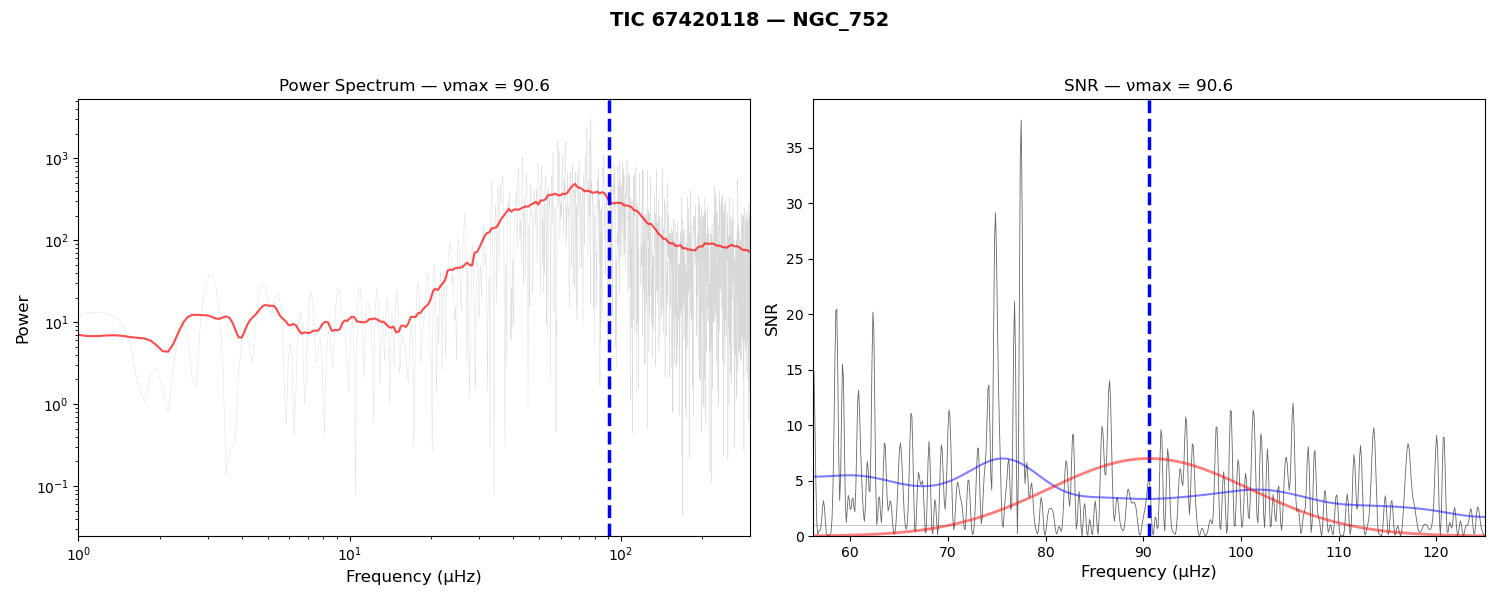

In [11]:
examine_numax(
    tic=67420118,
    numax_init=90.6,
    dnu_est=6.88,
    data_path='/Users/carlimankowski/research/revision/spoc_data/67420118_SPOC_PS.txt',
    cluster='NGC_752'
)

## TIC 186970424 — NGC 752 [SPOC]
Current νmax = 68.5, Δν = 6.51

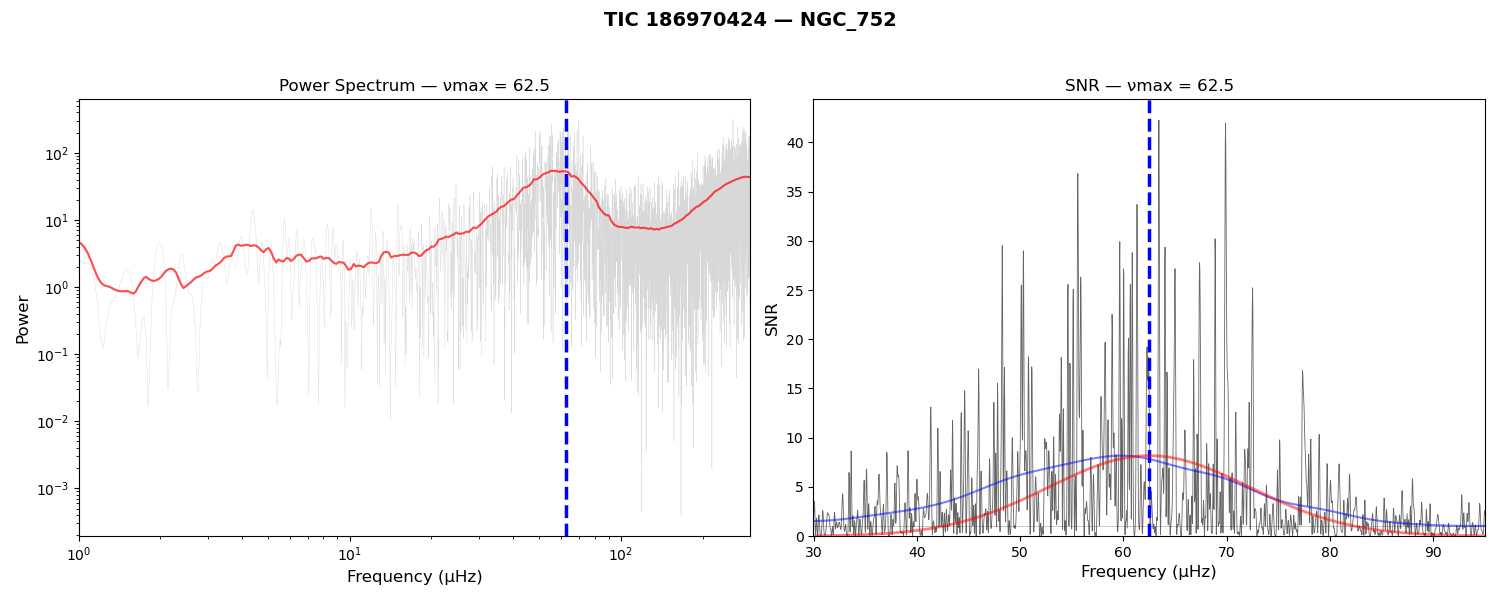

In [6]:
examine_numax(
    tic=186970424,
    numax_init=62.5,
    dnu_est=6.51,
    data_path='/Users/carlimankowski/research/revision/spoc_data/186970424_SPOC_PS.txt',
    cluster='NGC_752'
)

## TIC 67569102 — NGC 752 [SPOC]
Current νmax = 62.9, Δν = 5.72

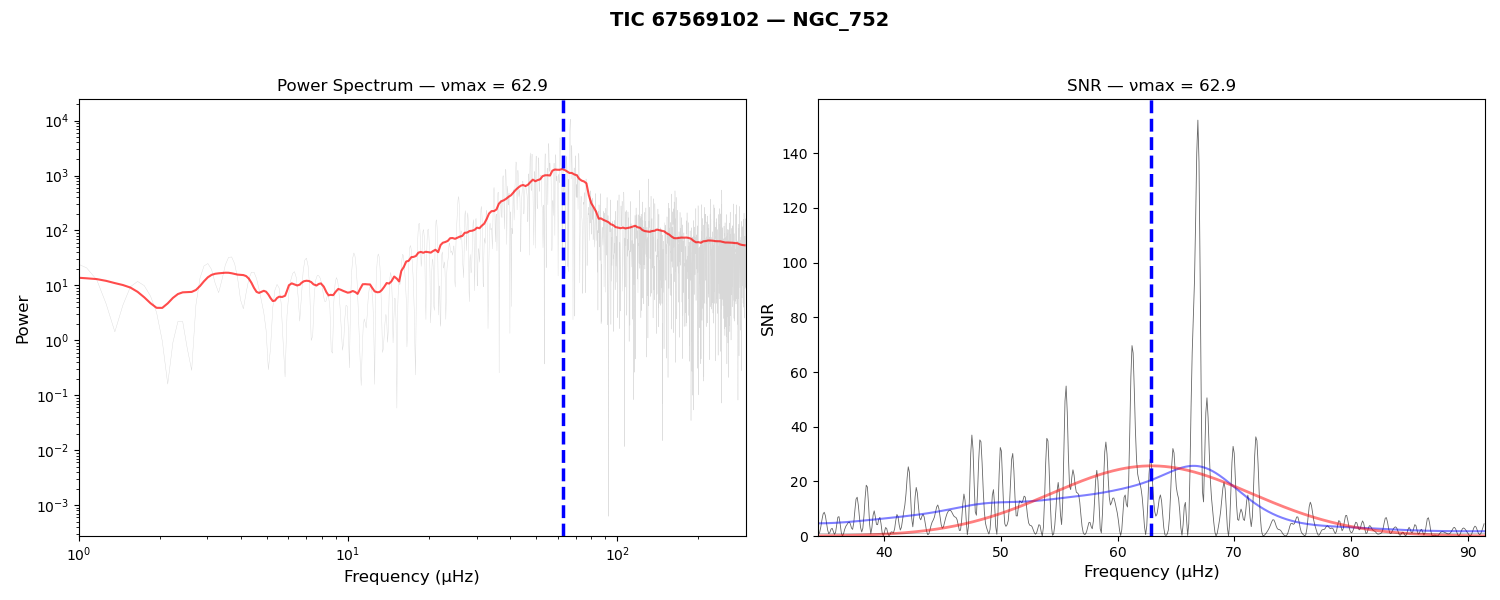

In [6]:
examine_numax(
    tic=67569102,
    numax_init=62.9,
    dnu_est=5.72,
    data_path='/Users/carlimankowski/research/revision/spoc_data/67569102_SPOC_PS.txt',
    cluster='NGC_752'
)

## TIC 67419922 — NGC 752 [QLP]
Current νmax = 42.0, Δν = 4.07

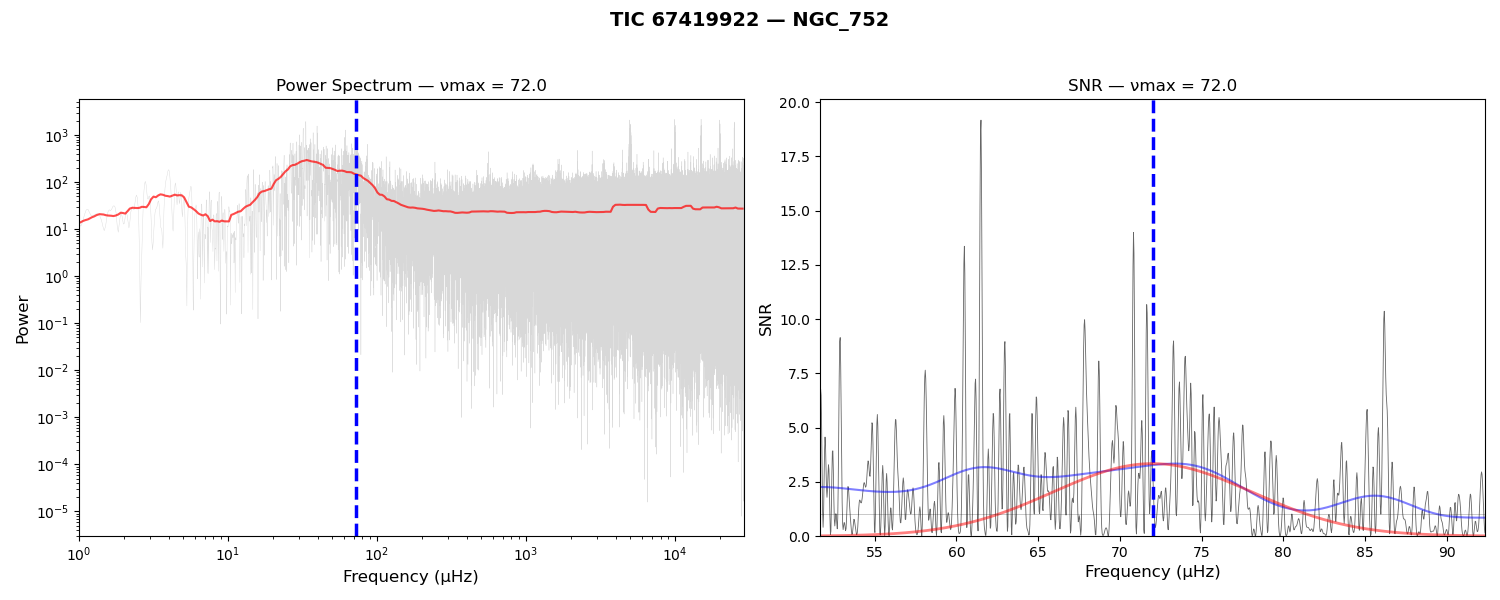

In [4]:
examine_numax(
    tic=67419922,
    numax_init=72.0,
    dnu_est=4.07,
    data_path='/Users/carlimankowski/research/data/67419922_PS.txt',
    cluster='NGC_752'
)